In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [15]:
# Dataset — salary based on experience, education, age
data = {
    "experience": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "education":  [12, 14, 14, 16, 16, 18, 18, 18, 20, 20],
    "age":        [22, 24, 25, 26, 27, 29, 30, 31, 33, 35],
    "salary":     [30000, 37000, 42000, 50000, 55000,
                   63000, 68000, 72000, 80000, 90000]
}

df = pd.DataFrame(data)
print(df.head())
print("")
print(df.describe())

   experience  education  age  salary
0           1         12   22   30000
1           2         14   24   37000
2           3         14   25   42000
3           4         16   26   50000
4           5         16   27   55000

       experience  education        age        salary
count    10.00000  10.000000  10.000000     10.000000
mean      5.50000  16.600000  28.200000  58700.000000
std       3.02765   2.674987   4.131182  19373.808207
min       1.00000  12.000000  22.000000  30000.000000
25%       3.25000  14.500000  25.250000  44000.000000
50%       5.50000  17.000000  28.000000  59000.000000
75%       7.75000  18.000000  30.750000  71000.000000
max      10.00000  20.000000  35.000000  90000.000000


experience    0.997321
education     0.977226
age           0.997598
salary        1.000000
Name: salary, dtype: float64


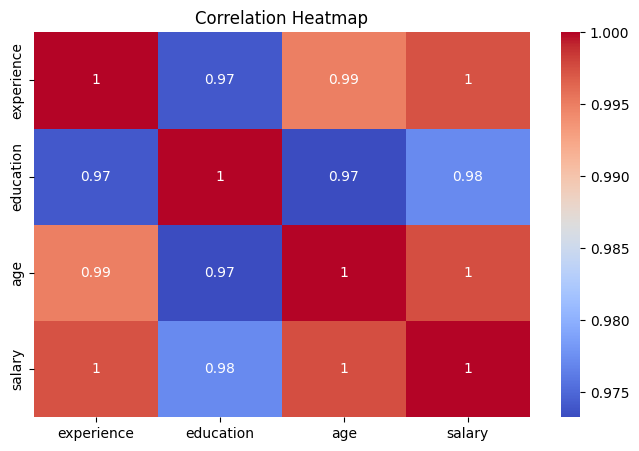

In [16]:
# Check correlation of each feature with salary
print(df.corr()["salary"])

# Heatmap — see all relationships
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Correlation close to 1 or -1 means strong relationship with salary.
This tells you which features are important.

In [17]:
# Features and Target
# Multiple features — this is the only change from Simple LR
X = df[["experience", "education", "age"]]
y = df["salary"]

print(f"X shape: {X.shape}")   # (10, 3) — 10 rows, 3 features
print(f"y shape: {y.shape}")   # (10,)   — 10 values

X shape: (10, 3)
y shape: (10,)


In [18]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train — same as Simple LR
model = LinearRegression()
model.fit(X_train, y_train)

# See what model learned for each feature
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature:12} : {coef:.2f}")
print(f"{'Intercept':12} : {model.intercept_:.2f}")

experience   : 1729.17
education    : 885.42
age          : 2875.00
Intercept    : -46229.17


In [19]:
# Predict
predictions = model.predict(X_test)

# Compare actual vs predicted
results = pd.DataFrame({
    "Actual"   : y_test.values,
    "Predicted": predictions.round(0)
})
print(results)

# Evaluate
mae  = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2   = r2_score(y_test, predictions)

print(f"\nMAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")

   Actual  Predicted
0   80000    81917.0
1   37000    38625.0

MAE  : 1770.83
RMSE : 1776.83
R2   : 0.9932


In [20]:
# New person — 5 years experience, 16 years education, 27 years old
new_person = pd.DataFrame([[5, 16, 27]],
             columns=["experience", "education", "age"])

predicted = model.predict(new_person)
print(f"Predicted salary: {predicted[0]:,.0f}")

Predicted salary: 54,208


In [21]:
# Compare Simple vs Multiple LR
# Simple LR — only experience
X_simple = df[["experience"]]
model_simple = LinearRegression()
model_simple.fit(X_train[["experience"]], y_train)
pred_simple = model_simple.predict(X_test[["experience"]])
r2_simple = r2_score(y_test, pred_simple)

# Multiple LR — all features
r2_multiple = r2_score(y_test, predictions)

print(f"Simple LR R2   : {r2_simple:.4f}")
print(f"Multiple LR R2 : {r2_multiple:.4f}")
print(f"Improvement    : {r2_multiple - r2_simple:.4f}")

# Multiple LR should give higher R2 — more features = better prediction.

Simple LR R2   : 0.9968
Multiple LR R2 : 0.9932
Improvement    : -0.0036
